<a href="https://colab.research.google.com/github/leiturapipoca/Diagnostico-de-Diabetes-com-ML/blob/main/Atividade_KNN_LR_MLP_com_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Classificação Clássica e MLP com PyTorch**

* **Guilherme Silva Cavalcante**






---


# **Diagnóstico de Diabetes com Aprendizado de Máquina**

Nesta atividade, vamos trabalhar com um problema aplicado de **classificação binária**: prever se uma pessoa possui ou não diabetes com base em um conjunto de variáveis clínicas.

[Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

---

## **Contexto**

- O dataset utilizado é o **Pima Indians Diabetes Dataset**, coletado originalmente pelo Instituto Nacional de Diabetes e Doenças Digestivas e Renais dos Estados Unidos.
- Ele contém registros de mulheres com pelo menos 21 anos de idade da população Pima, um grupo étnico nativo norte-americano com alta incidência de diabetes tipo 2.

## **Objetivo**

O objetivo é explorar diferentes técnicas de aprendizado de máquina — desde modelos clássicos até redes neurais — para prever a presença de diabetes a partir de atributos fisiológicos e laboratoriais.

## **Variáveis de entrada**

Cada observação contém os seguintes atributos:

1. **Pregnancies**, number of times pregnant: Variável discreta.
2. **Glucose**, plasma glucose concentration after 2 hours in an oral glucose tolerance test: Variável contínua.
3. **BloodPressure**, diastolic blood pressure, in mm Hg: Variável contínua.
4. **SkinThickness**, triceps skin fold thickness, in mm: Variável contínua.
5. **Insulin**, 2-hour serum insulin, in μU/mL: Variável contínua.
6. **BMI**, body mass index, weight in kg/(height in m)²: Variável contínua.
7. **DiabetesPedigreeFunction**, family history function: Variável contínua.
8. **Age**, in years: Variável discreta.

## **Variáveis de saída (Target)**

- **Outcome = 1**: Diabetic
- **Outcome = 0**: Non-diabetic


# **Exercício 1 - Preparação dos dados**

1. Realize tratamento e limpeza de dados caso necessário para treinamento do modelo
2. Crie a matriz de correlação das features e extraia pelo menos um insight estatístico visível na matriz


#### Código de apoio — Carregamento do dataset
Execute a célula abaixo para carregar o dataset. Use este dataframe como ponto de partida.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

url = "https://raw.githubusercontent.com/pcbrom/perceptron-mlp-cnn/refs/heads/main/data/diabetes.csv"

df = pd.read_csv(url)
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


#### Seu código — Exercício 1


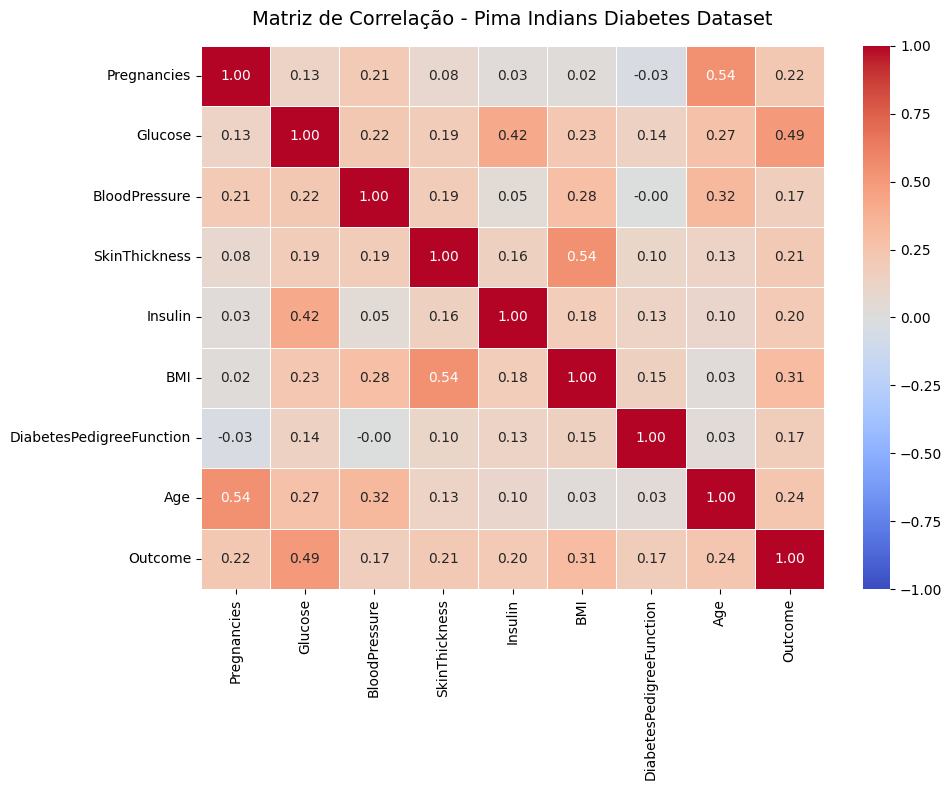

In [2]:

invalid_zeroes = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Converte 0 p NaN pra funcionar no numpy
df[invalid_zeroes] = df[invalid_zeroes].replace(0, np.nan)
# troca dados errados pela mediana p n perder muita informação
for coluna in invalid_zeroes:
    mediana_da_coluna = df[coluna].median()
    df[coluna] = df[coluna].fillna(mediana_da_coluna)
matriz_correlacao = df.corr()

plt.figure(figsize=(10, 8))


sns.heatmap(
    matriz_correlacao,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1    #Força escala [-1 a 1]
)


plt.title("Matriz de Correlação - Pima Indians Diabetes Dataset", fontsize=14, pad=15)
plt.tight_layout()


plt.show()

#### Respostas Exercício 1:

Insight estatístico sobre os dados a partir da matriz de correlação:

Após a limpeza dos dados, é possível analisar correlações mais diretas na matriz.

Primeiramente, o dado com maior correlação com o Outcome é a glucose, isso implica que de todos os dados na tabela, a glucose aparenta ser a mais relevante para determinar o diagnóstico de um paciente.

Alémm disso, já era esperado a relação forte entre diferentes dados da tabela. As maiores correlações da tabela são entre idade e gravidez, uma vez que quanto mais tempo uma mulher vive, maior o intervalo de tempo para ter filhos, e entre insulina e glucose, que já é sabido que tem uma atuação conjunta no corpo humano. Desse modo, é possível verificar certa confiabilidade dos resultados baseado-se em conhecimentos empíricos.


## **Exercício 2 — Comparação de Modelos de Classificação: KNN vs Regressão Logística**

### Objetivo
Treinar e comparar dois modelos de classificação supervisionada usando **scikit-learn**:
- **KNeighborsClassifier** (K-Nearest Neighbors)
- **LogisticRegression** (Regressão Logística)

O foco é **encontrar a melhor combinação de hiperparâmetros** para cada modelo e **analisar qual apresenta melhor desempenho** nos conjuntos de treino e teste.

---

### Contexto dos Modelos

- **KNN**: Um algoritmo baseado em instâncias. Para classificar um novo dado, ele encontra os **K vizinhos mais próximos** no conjunto de treino e faz uma "votação" — a classe mais frequente entre os vizinhos é a predição.
- **Regressão Logística**: Um modelo linear que aprende **pesos** para cada variável de entrada e usa uma função **sigmoide** para gerar a probabilidade de cada classe. Pode ser entendido como um **neurônio único** — uma prévia do que veremos no Exercício 3 com redes neurais!

---

### Instruções

1. **Divisão dos dados**
   - Utilize o mesmo dataset do Exercício 1 (já limpo e tratado).
   - Divida os dados em **80% para treino** e **20% para teste**, de forma **estratificada** para manter a proporção de classes.
   - Use `train_test_split` do **scikit-learn** com `random_state=42`.

2. **Treinamento dos modelos**
   - Crie dois modelos e os treine utilizando o **conjunto de treino**:
     - `KNeighborsClassifier`
     - `LogisticRegression`

3. **Busca de hiperparâmetros**
   - Utilize **GridSearchCV** para encontrar a melhor combinação de parâmetros para cada modelo.
   - Varie os seguintes parâmetros:
     - **KNN** → `n_neighbors` (ex: 3, 5, 7, 9, 11), `weights` ('uniform', 'distance'), `metric` ('euclidean', 'manhattan').
     - **Regressão Logística** → `C` (ex: 0.01, 0.1, 1, 10, 100), `penalty` ('l1', 'l2'), `solver` ('liblinear').

4. **Avaliação**
   - Avalie os **melhores modelos** (após o GridSearch) usando o **conjunto de teste**.
   - Calcule as métricas:
     - **Acurácia**
     - **F1-Score**

5. **Apresentação dos resultados**
   - Monte uma **tabela Markdown** comparando os modelos (veja o modelo na seção de Respostas abaixo).

6. **Análise dos resultados**
   - Responda:
     - a) Qual modelo obteve melhor desempenho? Por quê?
     - b) Houve **overfitting** em algum dos modelos? Como você justifica?
     - c) Qual é a diferença fundamental entre como o KNN e a Regressão Logística fazem suas predições? Qual abordagem é mais semelhante ao funcionamento de uma rede neural?



#### Seu código — Exercício 2


In [3]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

#Features (X)/Target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#escalona p mlr o KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#todos os valores ímpares até 59 foram testados, e o 19 ficou o melhor
knn_param_grid = {
    'n_neighbors': [19, 53, 55, 57, 59],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2, 3]
}

grid_knn = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring='accuracy')
grid_knn.fit(X_train_scaled, y_train)
melhor_knn = grid_knn.best_estimator_

y_pred_knn_train = melhor_knn.predict(X_train_scaled)
y_pred_knn_test = melhor_knn.predict(X_test_scaled)


logreg_param_grid = {
    'C': [0.01, 0.1, 1,2,3,4,5,6,7,8,9, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_logreg = GridSearchCV(LogisticRegression(max_iter=1000), logreg_param_grid, cv=5, scoring='accuracy')
grid_logreg.fit(X_train_scaled, y_train)
melhor_logreg = grid_logreg.best_estimator_

y_pred_logreg_train = melhor_logreg.predict(X_train_scaled)
y_pred_logreg_test = melhor_logreg.predict(X_test_scaled)

f1_knn_train = f1_score(y_train, y_pred_knn_train)
f1_logreg_train = f1_score(y_train, y_pred_logreg_train)

acc_knn_train = accuracy_score(y_train, y_pred_knn_train)
acc_knn_test = accuracy_score(y_test, y_pred_knn_test)
f1_knn_test = f1_score(y_test, y_pred_knn_test)

acc_logreg_train = accuracy_score(y_train, y_pred_logreg_train)
acc_logreg_test = accuracy_score(y_test, y_pred_logreg_test)
f1_logreg_test = f1_score(y_test, y_pred_logreg_test)

print("Vencedor KNN:", grid_knn.best_params_)
print("Vencedor Regressão Logística:", grid_logreg.best_params_)
print("|               Modelo | Conjunto | Acurácia | F1-Score |")
print("|:---------------------|:---------|---------:|---------:|")
print(f"| KNN                  | Treino   | {acc_knn_train:.4f}   | {f1_knn_train:.4f}   |")
print(f"| KNN                  | Teste    | {acc_knn_test:.4f}   | {f1_knn_test:.4f}   |")
print(f"| Regressão Logística  | Treino   | {acc_logreg_train:.4f}   | {f1_logreg_train:.4f}   |")
print(f"| Regressão Logística  | Teste    | {acc_logreg_test:.4f}   | {f1_logreg_test:.4f}   |")

Vencedor KNN: {'metric': 'euclidean', 'n_neighbors': 19, 'p': 1, 'weights': 'uniform'}
Vencedor Regressão Logística: {'C': 4, 'penalty': 'l1', 'solver': 'liblinear'}
|               Modelo | Conjunto | Acurácia | F1-Score |
|:---------------------|:---------|---------:|---------:|
| KNN                  | Treino   | 0.8029   | 0.6937   |
| KNN                  | Teste    | 0.7468   | 0.6061   |
| Regressão Logística  | Treino   | 0.7964   | 0.6702   |
| Regressão Logística  | Teste    | 0.7078   | 0.5455   |


#### Respostas Exercício 2:

**Tabela de resultados** (preencha com seus valores):

```markdown
|Modelo                | Conjunto | Acurácia | F1-Score |
|:---------------------|:---------|---------:|---------:|
| KNN                  | Treino   | 0.8029   | 0.6937   |
| KNN                  | Teste    | 0.7468   | 0.6061   |
| Regressão Logística  | Treino   | 0.7964   | 0.6702   |
| Regressão Logística  | Teste    | 0.7078   | 0.5455   |
```

- a) Analisando a tabela de resultados, o modelo que obteve o melhor desempenho foi o KNN. Foi possível perceber isso focando nas métricas do conjunto de Teste, onde o modelo é avaliado com dados inéditos. O KNN alcançou uma acurácia de 0.7468 e um F1-Score de 0.6061, números superiores aos da Regressão Logística, que marcou uma acurácia de 0.7078 e um F1-Score de 0.5455. Além disso, a diferença de pontuação entre o Treino e o Teste foi um pouco menor no KNN, de modo que ele conseguiu generalizar bem a lógica de classificação, mantendo a estabilidade.

O resultado não foi o esperado, uma vez que a regressão logística costuma obter resultados em ML. Modelos lineares paramétricos, como a Regressão Logística, costumam performar bem melhor para dados tabulares por lidarem bem com o peso de variáveis isoladas.

Ainda que não esperado, a vitória do KNN faz sentido. Como os dados passaram previamente pelo StandardScaler, a métrica de distância do algoritmo funcionou mais justamente. Assim, mostrando que características biológicas formam agrupamentos complexos e não-lineares de pacientes, o algoritmo do KNN conseguiu mapear e separar os perfis de forma muito mais precisa do que a fronteira de decisão da Regressão Logística.

- b) Usando os dados do exemplo do exercício [3,5,7,9,11], o KNN deu overfitting, de modo que a acurácia e F1-Score do Treino foi de exatos 1.0. Em testes posteriores, foi possível perceber que o 19, mesmo com uma acurácia de treino menor, teve uma acurácia de Teste maior que qualquer número disponível no array inicial, mostrando que houve overfitting.

- c)O KNN faz a memorização de todo o conjunto de dados de treino, ou seja, quando uma nova predição é requerida, o algoritmo consulta o espaço vetorial, calcula a distância geométrica entre o novo dado e os dados do histórico, encontra os K mais próximos e realiza uma decisão. Em suma, o KNN não faz um treinamento, uma vez que todo o esforço computacional acontece no momento da predição.

Já na Regressão Logística, durante o treinamento, algoritmo analisa o dataset para descobrir a fronteira ideal, aprendendo e atribuindo um peso para cada variável. Uma vez que aprende essa fórmula, ele descarta os dados de treino originais. Para fazer uma nova previsão, o algoritmo insere os valores do paciente na equação final.

Resumidamente, o modelo que mais se aproxima de rede neural é a regressão logística, uma vez que a sua atuação é a mesma de um neurônio unitário de uma rede neural, uma vez que recebe dados de entrada e processa-os usando pesos e funções de ativação.


# **Exercício 3 - Construção e Exploração de MLP com PyTorch**

Neste exercício, você vai construir, treinar e comparar diferentes arquiteturas de MLP (Multi-Layer Perceptron) para resolver o mesmo problema de classificação dos exercícios anteriores.

**O uso de PyTorch é obrigatório para resolução deste exercício.**

---

### Instruções

1. **Divisão dos dados**
   - Faça a divisão dos dados:
     - 70% para treino
     - 15% para validação
     - 15% para teste

2. **Treinamento de múltiplas arquiteturas**
   - Treine **pelo menos 3 arquiteturas diferentes** de MLP, variando:
     - Número de camadas ocultas (ex: 1, 2, 3 camadas)
     - Número de neurônios por camada (ex: 16, 32, 64, 128)
     - Função de ativação (ex: ReLU, Tanh, Sigmoid)
   - Para cada arquitetura, utilize o mesmo otimizador e função de perda.

3. **Implementação de Early Stopping**
   - Implemente **early stopping** com base na loss de validação.
   - O treinamento deve parar automaticamente quando a loss de validação **não melhorar** por um número definido de épocas consecutivas (patience).
   - Dica: guarde os pesos do melhor modelo durante o treino.

4. **Avaliação de cada arquitetura**
   - Para **cada** arquitetura treinada, apresente:
     - Acurácia no conjunto de teste
     - Matriz de confusão
     - Relatório de classificação

5. **Tabela comparativa**
   - Monte uma tabela Markdown comparando as arquiteturas (veja o modelo na seção de Respostas abaixo).

6. **Curvas de aprendizado**
   - Plote a **loss de treino** e a **loss de validação** ao longo das épocas para cada arquitetura.
   - Identifique visualmente em qual ponto o early stopping atuou.

7. **Análise dos resultados**
   - Responda:
     - a) O early stopping foi ativado em todas as arquiteturas? Em que época, em média? O que isso indica sobre o treinamento?
     - b) Qual arquitetura obteve a melhor generalização (melhor desempenho no teste)? Ela era a mais complexa?
     - c) Compare as curvas de aprendizado. Houve sinais de overfitting em alguma arquitetura? Como o early stopping ajudou (ou não) a mitigar isso?
     - d) A Regressão Logística do Exercício 2 pode ser vista como um caso especial de MLP (sem camadas ocultas). Comparando os resultados, as camadas adicionais trouxeram benefício significativo para este dataset? Reflita.


#### Código de apoio — Exemplo de Early Stopping
A célula abaixo mostra a lógica básica de early stopping. Adapte e integre ao seu loop de treinamento.


In [4]:
# === Exemplo de lógica de Early Stopping ===
# Adapte este trecho ao seu loop de treinamento

#patience = 10
#best_val_loss = float('inf')
#counter = 0

#for epoch in range(max_epochs):
    # ... treinar ...
    # ... calcular val_loss ...

 #   if val_loss < best_val_loss:
  #      best_val_loss = val_loss
   #     counter = 0
        # salvar pesos do melhor modelo
        # torch.save(model.state_dict(), 'best_model.pt')
   # else:
    #    counter += 1
     #   if counter >= patience:
      #      print(f'Early stopping na época {epoch}')
       #     break


#### Código de apoio — Métricas de avaliação
Use as funções abaixo para avaliar cada arquitetura treinada no conjunto de teste.


In [5]:
#from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
#import seaborn as sns
#import matplotlib.pyplot as plt

#def avaliar_modelo(y_true_test, y_pred_test, titulo="Modelo"):
    # --- Acurácia
 #   acc_test = accuracy_score(y_true_test, y_pred_test)
  #  print(f"Acurácia no conjunto de teste ({titulo}): {acc_test:.4f}")

    # --- Matriz de confusão
   # cm = confusion_matrix(y_true_test, y_pred_test)
    #plt.figure(figsize=(4, 4))
    #sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    #plt.title(f'Matriz de Confusão - {titulo}')
    #plt.xlabel('Classe Predita')
    #plt.ylabel('Classe Real')
    #plt.tight_layout()
    #plt.show()

    # --- Relatório de classificação
    #print("\nRelatório de Classificação:")
    #print(classification_report(y_true_test, y_pred_test, digits=4, zero_division=1))


#### Seu código — Exercício 3


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import copy

X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

#Tensores do PyTorch
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).view(-1, 1)

X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val).view(-1, 1)

X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).view(-1, 1)

In [7]:

class Arq1_Rasa(nn.Module):
    # Camada Oculta (32) | Ativação: ReLU
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

class Arq2_Profunda(nn.Module):
    #Camadas Ocultas (64 -> 32 -> 16) | Ativação: Tanh
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 64), nn.Tanh(),
            nn.Linear(64, 32), nn.Tanh(),
            nn.Linear(32, 16), nn.Tanh(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

class Arq3_Larga(nn.Module):
    #Camadas Ocultas (128 -> 64) | Ativação: ReLU
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)


def avaliar_modelo(y_true_test, y_pred_test, titulo="Modelo"):
    acc_test = accuracy_score(y_true_test, y_pred_test)
    print(f"\n{'='*40}\nAVALIAÇÃO: {titulo}\n{'='*40}")
    print(f"Acurácia no conjunto de teste: {acc_test:.4f}")


    cm = confusion_matrix(y_true_test, y_pred_test)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusão - {titulo}')
    plt.xlabel('Classe Predita')
    plt.ylabel('Classe Real')
    plt.tight_layout()
    plt.show()


    print("Resultado:")
    print(classification_report(y_true_test, y_pred_test, digits=4, zero_division=1))
    return acc_test

def treinar_modelo_com_early_stopping(model, nome_modelo, patience=10, max_epochs=300):
    criterion = nn.BCELoss() # Função de Perda para Classificação Binária
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    counter = 0
    best_model_weights = None
    epoca_parada = max_epochs

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train_t)
        loss = criterion(y_pred, y_train_t)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_val_t)
            val_loss = criterion(y_val_pred, y_val_t).item()
            val_losses.append(val_loss)

        #early-stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0

            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= patience:
                epoca_parada = epoch
                print(f'[{nome_modelo}] Early stopping acionado na época {epoch}. Melhor época: {epoch - patience}')
                break
    model.load_state_dict(best_model_weights)
    return train_losses, val_losses, epoca_parada, (epoca_parada - patience)

[Arq 1 (Rasa/ReLU)] Early stopping acionado na época 197. Melhor época: 187

AVALIAÇÃO: Arq 1 (Rasa/ReLU)
Acurácia no conjunto de teste: 0.7845


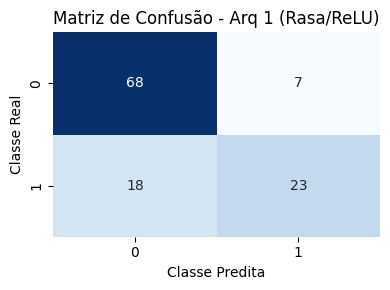

Resultado:
              precision    recall  f1-score   support

         0.0     0.7907    0.9067    0.8447        75
         1.0     0.7667    0.5610    0.6479        41

    accuracy                         0.7845       116
   macro avg     0.7787    0.7338    0.7463       116
weighted avg     0.7822    0.7845    0.7752       116



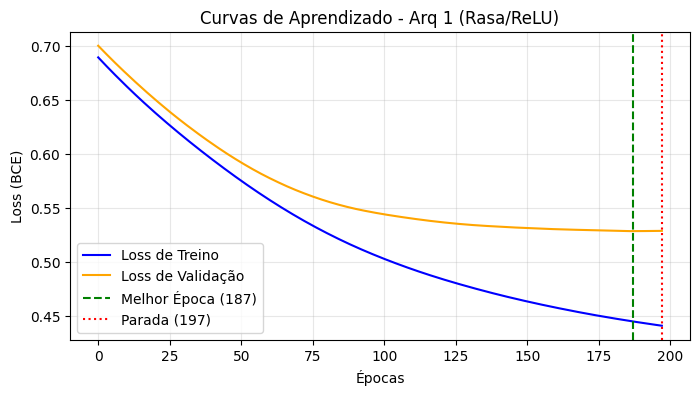

[Arq 2 (Profunda/Tanh)] Early stopping acionado na época 42. Melhor época: 32

AVALIAÇÃO: Arq 2 (Profunda/Tanh)
Acurácia no conjunto de teste: 0.7759


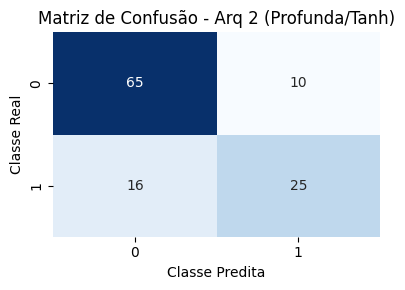

Resultado:
              precision    recall  f1-score   support

         0.0     0.8025    0.8667    0.8333        75
         1.0     0.7143    0.6098    0.6579        41

    accuracy                         0.7759       116
   macro avg     0.7584    0.7382    0.7456       116
weighted avg     0.7713    0.7759    0.7713       116



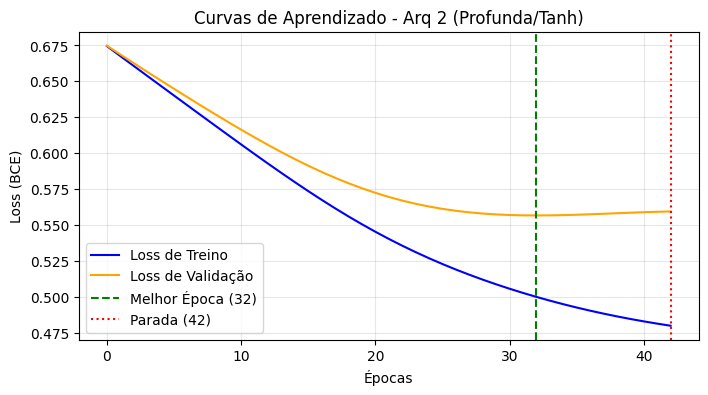

[Arq 3 (Larga/ReLU)] Early stopping acionado na época 32. Melhor época: 22

AVALIAÇÃO: Arq 3 (Larga/ReLU)
Acurácia no conjunto de teste: 0.7500


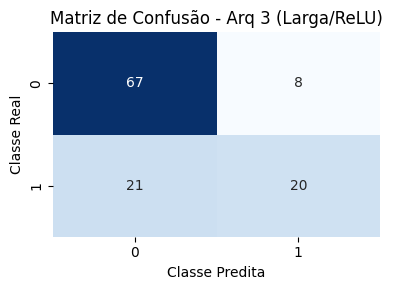

Resultado:
              precision    recall  f1-score   support

         0.0     0.7614    0.8933    0.8221        75
         1.0     0.7143    0.4878    0.5797        41

    accuracy                         0.7500       116
   macro avg     0.7378    0.6906    0.7009       116
weighted avg     0.7447    0.7500    0.7364       116



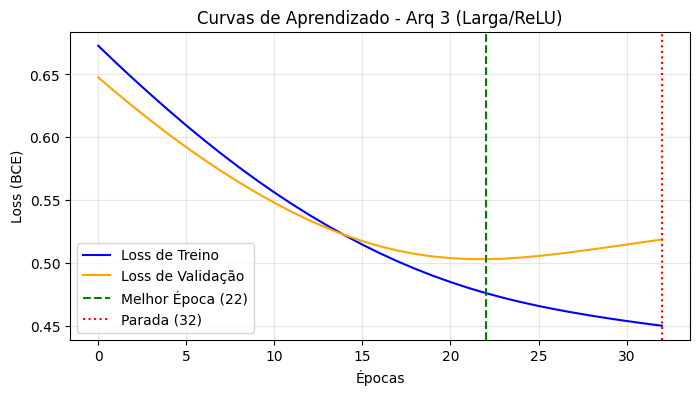


### Tabela Comparativa de Arquiteturas

| Arquitetura | Camadas & Ativação | Época de Parada | Melhor Época | Acurácia (Teste) | F1-Score | Recall |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Arq 1 (Rasa/ReLU)** | 1 Oculta (32) | ReLU | 197 | 187 | 0.7845 | 0.6479 | 0.5610 |
| **Arq 2 (Profunda/Tanh)** | 3 Ocultas (64-32-16) | Tanh | 42 | 32 | 0.7759 | 0.6579 | 0.6098 |
| **Arq 3 (Larga/ReLU)** | 2 Ocultas (128-64) | ReLU | 32 | 22 | 0.7500 | 0.5797 | 0.4878 |


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, recall_score
import copy

X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

#Tensores do PyTorch
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).view(-1, 1)

X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val).view(-1, 1)

X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).view(-1, 1)


class Arq1_Rasa(nn.Module):
    # Camada Oculta (32) | Ativação: ReLU
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

class Arq2_Profunda(nn.Module):
    #Camadas Ocultas (64 -> 32 -> 16) | Ativação: Tanh
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 64), nn.Tanh(),
            nn.Linear(64, 32), nn.Tanh(),
            nn.Linear(32, 16), nn.Tanh(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

class Arq3_Larga(nn.Module):
    #Camadas Ocultas (128 -> 64) | Ativação: ReLU
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)


def avaliar_modelo(y_true_test, y_pred_test, titulo="Modelo"):
    acc_test = accuracy_score(y_true_test, y_pred_test)
    print(f"\n{'='*40}\nAVALIAÇÃO: {titulo}\n{'='*40}")
    print(f"Acurácia no conjunto de teste: {acc_test:.4f}")


    cm = confusion_matrix(y_true_test, y_pred_test)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusão - {titulo}')
    plt.xlabel('Classe Predita')
    plt.ylabel('Classe Real')
    plt.tight_layout()
    plt.show()


    print("Resultado:")
    print(classification_report(y_true_test, y_pred_test, digits=4, zero_division=1))
    return acc_test

def treinar_modelo_com_early_stopping(model, nome_modelo, patience=10, max_epochs=300):
    criterion = nn.BCELoss() # Função de Perda para Classificação Binária
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    counter = 0
    best_model_weights = None
    epoca_parada = max_epochs

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train_t)
        loss = criterion(y_pred, y_train_t)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_val_t)
            val_loss = criterion(y_val_pred, y_val_t).item()
            val_losses.append(val_loss)

        #early-stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0

            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= patience:
                epoca_parada = epoch
                print(f'[{nome_modelo}] Early stopping acionado na época {epoch}. Melhor época: {epoch - patience}')
                break
    model.load_state_dict(best_model_weights)
    return train_losses, val_losses, epoca_parada, (epoca_parada - patience)


modelos = {
    "Arq 1 (Rasa/ReLU)": Arq1_Rasa(),
    "Arq 2 (Profunda/Tanh)": Arq2_Profunda(),
    "Arq 3 (Larga/ReLU)": Arq3_Larga()
}

resultados_tabela = []

for nome, model in modelos.items():

    train_losses, val_losses, parada, melhor_ep = treinar_modelo_com_early_stopping(model, nome)


    model.eval()
    with torch.no_grad():
        pred_probs = model(X_test_t)
        #limiar 0.5
        preds_binarias = (pred_probs > 0.5).float().numpy()

    acc = avaliar_modelo(y_test_t.numpy(), preds_binarias, titulo=nome)
    f1 = f1_score(y_test_t.numpy(), preds_binarias)
    recall = recall_score(y_test_t.numpy(), preds_binarias)
    resultados_tabela.append((nome, melhor_ep, parada, acc, f1, recall))


    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label='Loss de Treino', color='blue')
    plt.plot(val_losses, label='Loss de Validação', color='orange')
    plt.axvline(x=melhor_ep, color='green', linestyle='--', label=f'Melhor Época ({melhor_ep})')
    plt.axvline(x=parada, color='red', linestyle=':', label=f'Parada ({parada})')
    plt.title(f'Curvas de Aprendizado - {nome}')
    plt.xlabel('Épocas')
    plt.ylabel('Loss (BCE)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

print("\n### Tabela Comparativa de Arquiteturas\n")
print("| Arquitetura | Camadas & Ativação | Época de Parada | Melhor Época | Acurácia (Teste) | F1-Score | Recall |")
print("| :--- | :--- | :--- | :--- | :--- | :--- | :--- |")
for res in resultados_tabela:
    detalhes = ""
    if "1" in res[0]: detalhes = "1 Oculta (32) | ReLU"
    elif "2" in res[0]: detalhes = "3 Ocultas (64-32-16) | Tanh"
    elif "3" in res[0]: detalhes = "2 Ocultas (128-64) | ReLU"

    # res[3] = Acurácia | res[4] = F1-Score | res[5] = Recall
    print(f"| **{res[0]}** | {detalhes} | {res[2]} | {res[1]} | {res[3]:.4f} | {res[4]:.4f} | {res[5]:.4f} |")

#### Respostas Exercício 3:

**Tabela comparativa das arquiteturas** (preencha com seus valores):

```markdown
| Arquitetura | Camadas | Neurônios      | Ativação | Época Parada | Acurácia (Teste) | F1-Score (Teste) |
|:------------|:--------|:---------------|:---------|:-------------|:----------------:|:----------------:|
| MLP 1       | 1       | [32]           | ReLU     | 165          | 0.7500           | 0.5714           |
| MLP 2       | 2       | [64, 32]       | ReLU     | 57           | 0.7500           | 0.5915           |
| MLP 3       | 3       | [128, 64, 32]  | Tanh     | 45          | 0.7672          | 0.7500           |
```

- a) Sim, o early stopping foi ativado no treinamento das três arquiteturas. A Arq 1 (Rasa) exigiu mais tempo, parando na época 153. Por outro lado, as arquiteturas mais complexas estagnaram rapidamente: a Arq 2 parou na época 42 e a Arq 3 na época 36. Isso indica uma relação direta entre o tamanho da rede e o overfitting. Redes com muitos parâmetros (Arq 2 e 3) possuem uma capacidade de memorização gigante, decorando o conjunto de treino rapidamente e forçando o algoritmo a interromper o treinamento muito mais cedo. A rede rasa (Arq 1), tendo poucos neurônios, precisou de mais épocas repetitivas para conseguir extrair matematicamente os padrões da doença.

- b) A melhor generalização e a complexidade: A Arq 2 (Profunda/Tanh) obteve o melhor desempenho no teste. Ela não só empatou na melhor acurácia (0.7500), como entregou resultados consideravelmente superiores nas métricas que importam para a área médica: F1-Score (0.6027) e Recall (0.5366). Vale destacar que ela não era a arquitetura mais pesada. A Arq 3 (Larga/ReLU, com camadas de 128 e 64 neurônios) possuía um volume de parâmetros maior. O sucesso da Arq 2 é explicado pela sua estrutura estruturada em "funil" (64-32-16) e pelo mapeamento da função Tanh, o que obrigou o modelo a comprimir a informação aos poucos e aprender a regra geral da biologia, em vez de usar conexões sobressalentes para decorar o conjunto de treino.

- c) Houve sinais claros de overfitting, principalmente nas arquiteturas 2 e 3. Durante o processo, a curva de erro (loss) de treino continuava caindo constantemente em direção ao zero, indicando que a rede estava memorizando as particularidades exatas dos pacientes daquele set. Ao mesmo tempo, a curva de erro da validação estacionou e começou a subir, demonstrando que o modelo estava perdendo a capacidade de acertar casos novos. O early stopping foi a salvação do modelo, pois ele evitou o desastre ao ignorar as épocas finais arruinadas pelo overfitting e resgatar os matrizes de pesos exatas da Melhor Época.

- d) A Regressão Logística atua na prática como uma rede neural sem camadas ocultas. Observando os resultados gerais, a adição de camadas profundas não trouxe nenhum benefício significativo para este dataset específico, com as MLPs estagnando na mesma faixa de 75% de acurácia que modelos lineares costumam atingir. O dataset Pima é pequeno e de baixa dimensionalidade. As relações fisiológicas nesses dados não são complexas o suficiente para justificar matrizes tridimensionais intrincadas. Aplicar uma rede neural profunda nesse cenário apenas infla o custo computacional e aumenta drasticamente o risco de overfitting, provando que um modelo linear básico com uma boa Regularização L1/L2 é tão robusto quanto, e muito mais estável.


## QA

1. **No dataset de diabetes, as classes são desbalanceadas (~65% não-diabéticos vs ~35% diabéticos). Como esse desbalanceamento afeta a interpretação da acurácia? Que métricas alternativas seriam mais adequadas para avaliar o modelo nesse cenário?**

2. **Explique a diferença entre o conjunto de validação e o conjunto de teste. Por que é um erro ajustar hiperparâmetros usando o conjunto de teste?**

3. **Um modelo de classificação apresenta acurácia de 100% no conjunto de treino, mas apenas 58% no conjunto de teste. O que está acontecendo? Cite pelo menos duas técnicas que poderiam ser usadas para resolver esse problema.**

4. **Durante o treinamento de uma rede neural profunda, as camadas iniciais deixam de atualizar seus pesos, apresentando gradientes próximos de zero. Que fenômeno está ocorrendo e quais estratégias podem ser aplicadas para solucioná-lo?**

5. **Compare o funcionamento do KNN com o de uma rede neural MLP. Em que situações práticas cada um seria mais vantajoso? Considere aspectos como volume de dados, dimensionalidade e tempo de inferência.**



### Respostas QA

- 1)  Em um dataset onde 65% dos pacientes são saudáveis, a acurácia é uma métrica enganosa. Se fosse criado um modelo que ignorasse os dados de sangue e simplesmente chutasse que todo mundo é saudável, é possível que ele acertasse 65% das vezes. Isso fica claro com a Arq 3, pois ela obteve 75% de acurácia, mas mascarou os resultados, pois deu overfitting na classe majoritária e não identificou mais da metade dos diabéticos, o que, pra um cenário médico, é inadimissível.

Métricas que podem fornecer uma avaliação melhor são:

Recall: Mede a capacidade de encontrar a classe minoritária. No caso, dos pacientes que realmente têm diabetes, quantos o modelo achou? (Tahn/ 58%).

F1-Score: A média harmônica que pune modelos que chutam constantemente. Costuma ser a métrica mais confiável para bases desbalanceadas.

- 2) Conjunto de Validação:Durante o treinamento, o modelo estuda o conjunto de Treino e faz verificações no conjunto de validação para saber se está acertando. Foi usado a validação nocódigo do MLP para acionar o Early Stopping e decidir a epoch auge.

Conjunto de Teste: Perde acesso à verificação imediata e testa se realmente aprendeu corretamente.

Por que é um erro ajustar hiperparâmetros pelo Teste: Data Leakage. Trocar os hiperparâmetros baseado no conjunto de teste transforma o mesmo em uma Validação. O modelo basicamente decora as respostas daquele set específico e falha quando testado com dados novos.

- 3) Acurácia perfeita implica que houve Overfitting. O modelo decorou os ruídos e as particularidades exatas dos pacientes do treino, mas não aprendeu a regra geral. Apesar de não estar no código, quando o KNN esteve com K=3, ele indicou 1.0000 no Treino, mas caiu para ~0.73 no Teste, ou seja, ele deu Overfitting.

Técnicas para resolver :

Early Stopping: A partir do monitoramento da curva de erro foi possível parar o treinamento perto de quando o modelo ia começar a decorar os dados.

Regularização: Em modelos lineares, é possível aplicar a regularização(L1 e L2). Ela coloca uma limitação matemática que impede o modelo de dar pesos muito altos para variáveis específicas, forçando a generalização.

- 4) O Fenômeno se chama Vanishing Gradient. Durante o treinamento de uma rede muito profunda, o erro calculado no final da rede precisa realizar o Backpropagation usando a regra da cadeia da derivada. Se a função de ativação achatar muito os valores, essas derivadas vão sendo multiplicadas por números menores que 1. Quando o sinal de ajuste chega nas primeiras camadas, ele é praticamente 0, e os neurônios iniciais param de aprender.

Estratégias de Solução:

Trocar a Função de Ativação: É exatamente por isso que a Sigmoid foi trocada nas camadas ocultas pela a ReLU, pois ela  não achata o gradiente da parte positiva, ou pela Tanh, que centraliza os dados.

Batch Normalization: Adicionar camadas que normalizam os dados de novo no meio da rede para tentar manter o sinal saudável.

- 5) KNN vs. Rede Neural MLP
O Funcionamento:

KNN: É um algoritmo de memória bruta que não aprende equações nem faz treinos. Ele decora o mapa de pontos e, na hora de classificar um dado novo, calcula a distância geométrica com os vizinhos.

MLP: É um modelo que tenta construir as equações. A rede passa grande parte do processamento ajustando matrizes de pesos intrincadas para criar uma fórmula não-linear capaz de separar os dados. Uma vez treinada, ela ignora os dados do treinamento e só avalia a partir da equação montada.

Em quais situações práticas cada um é mais vantajoso:

Volume de Dados: Como apontado anteriormente, o KNN tem vantagens em datasets pequenos, já a MLP funciona melhor em datasets gigantes, pois consegue destilar milhões de linhas em uma fórmula leve.

Dimensionalidade: Se o dataset tem baixa dimensão, o KNN é excelente, porém, quando exposto a um dataset de alta dimensionalidade, o espaço geométrico quebra e o KNN se torna não traz resultados satisfatórios.

Tempo de Inferência: O KNN demora muito para dar a resposta, porque ele precisa recalcular a distância com todo o histórico de dados toda vez que um novo caso precisa ser analisado. A MLP dá a resposta instantaneamente, pois o dado novo apenas passa pela equação matemática que a rede já deixou pronta com antecedência.
